Date:

Author: Mehedi Hasan

Project description Summery:

In this notebook I aim to do a network analysis and generage graphs to visualize the networks. I simulated the the best known example of network analysis "Zacharys's Karate CLub" which Wayane Zachary wrote in his paper "An Information FLow Model for Conflict and Fission in small Groups" publised in 1977



In [ ]:
# Importing necessery libraries

import sys
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
zkc_graph = nx.karate_club_graph()
Mr_Jerry = 0
Jhon = 33
club_labels = nx.get_node_attributes(zkc_graph, 'club') # Defining the variable
print({key:club_labels[key] for key in range(10,16)})

{10: 'Mr. Hi', 11: 'Mr. Hi', 12: 'Mr. Hi', 13: 'Mr. Hi', 14: 'Officer', 15: 'Officer'}


Note: Here the "officer" means "Jhon"

We imported the "zkc" graph successfully. We can view the the relationship of the  "zkc" graph in Matrix. In Data Science we often need to convert graph into Matrix.

In [ ]:
# Converitng "zkc" graph into "Matrix"
A_Matrix = nx.convert_matrix.to_numpy_array(zkc_graph)
A_Matrix

array([[0., 4., 5., ..., 2., 0., 0.],
       [4., 0., 6., ..., 0., 0., 0.],
       [5., 6., 0., ..., 0., 2., 0.],
       ...,
       [2., 0., 0., ..., 0., 4., 4.],
       [0., 0., 2., ..., 4., 0., 5.],
       [0., 0., 0., ..., 4., 5., 0.]])

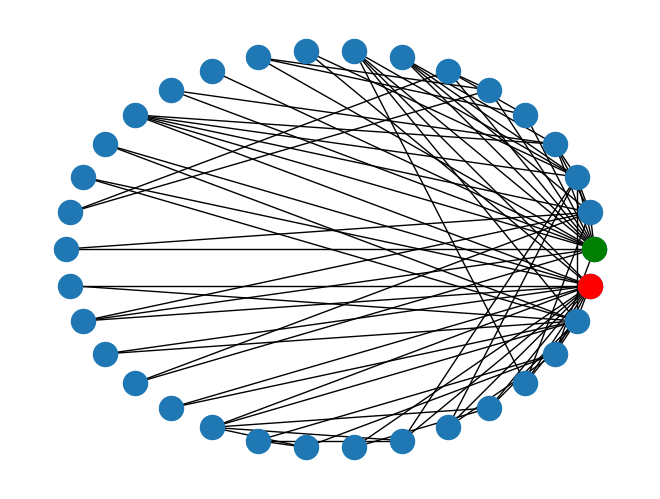

In [ ]:
# Visialization a Network/Matrix

circular_position = nx.circular_layout(zkc_graph)
nx.draw(zkc_graph, circular_position) # draw method to draw the network, the draw method takes two argument (1) zkc_graph, (2) circular_position variable

# We can identify "Mr Jerry" and "Jhon" by assinging color

nx.draw_networkx_nodes(zkc_graph, circular_position, nodelist=[Mr_Jerry], node_color='green', alpha=1)
nx.draw_networkx_nodes(zkc_graph, circular_position, nodelist=[Jhon], node_color='red', alpha=1)


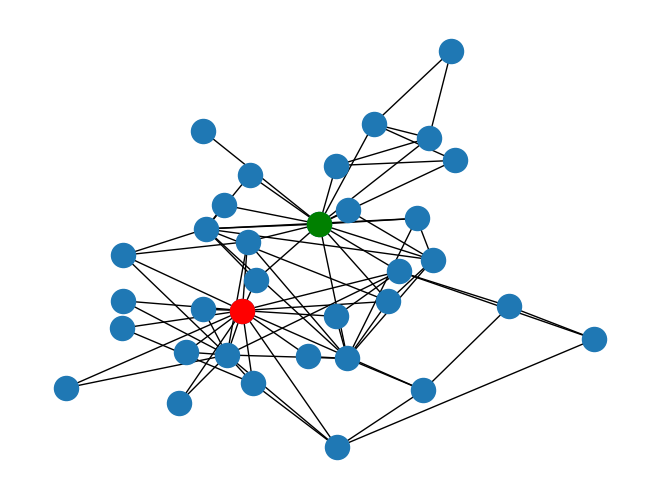

In [ ]:
# Drawing the same graph with kamada_kawai_position, common for social network visualization

kamada_kawai_position = nx.kamada_kawai_layout(zkc_graph)

nx.draw(zkc_graph, kamada_kawai_position)  # draw method to draw the network, the draw method takes two arguments (1) zkc_graph, (2) kamada_kawai_position variable

# We can identify "Mr Jerry" and "Jhon" by assigning color

nx.draw_networkx_nodes(zkc_graph,kamada_kawai_position,nodelist=[Mr_Jerry],node_color='green',alpha=1)

nx.draw_networkx_nodes(zkc_graph,kamada_kawai_position,nodelist=[Jhon],node_color='red',alpha=1)

To analyze a network, the fist thing we need to do is to find out the density. It is a comparison between a existing nummber of edges and a maximum possible edges. For Example: Density 1.0 means every possible edge exists in a network, in contrast density 0.0 means there is connection among the nodes. Therefor, It is very important to know the density of any network, because it tells us the scope of new connectivity. In other words, it tells us the current status of a network.

In [ ]:
# Finding the density of the network

density = nx.density(zkc_graph)
print("The edge density is: " + str(density))

The edge density is: 0.13903743315508021


Now we can look at the degree, which indicates how many edges each node has. This is a typical centrality matrics. It indicates how important each node is in a network. The notion is that, nodes with most edges are the most important or central as they are directly related to plenty or other nodes. Nodes hving a high centrality could be expected to play a central role in the network.

In [ ]:
# Measuing degree
degree = zkc_graph.degree()
degree_list = []

for (n, d) in degree:
  degree_list.append(d)

avg_degree = sum(degree_list) / len (degree_list) # Calculting the average of the degree
print("The average degree is: " + str(avg_degree))

The average degree is: 4.588235294117647


Here, we can see the average degree is 4.5882. I will plot the degree distribution for better insights.

Text(0.5, 1.0, 'Node Degree')

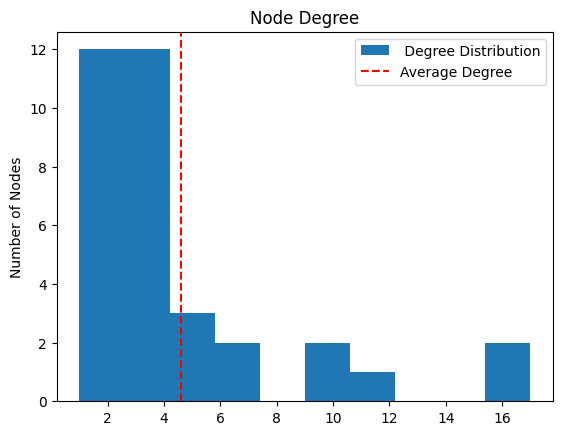

In [ ]:
# Ploting the degree
plt.hist(degree_list, label= " Degree Distribution")
plt.axvline(avg_degree, color='red', linestyle='dashed', label='Average Degree')
plt.legend()
plt.ylabel('Number of Nodes')
plt.title('Node Degree')

The clustering coeffient is another important statistic of network analysis. A network is formed through the interconnection of nodes. A node can be connected with multiple other nodes. Those can be connected among themselves as well. Together it formes a cluster. A cluster is like a group inside of a netwrok who are morentightly connected. For example: In a social media perspective, we get a suggestion to connect with people based on their connection. The measurement used to find out the people we may be interested to get connecting is called the "Clustering Coeffiecient".


**Let's mesure the clustering coeffient of the network and express it graphicly.**

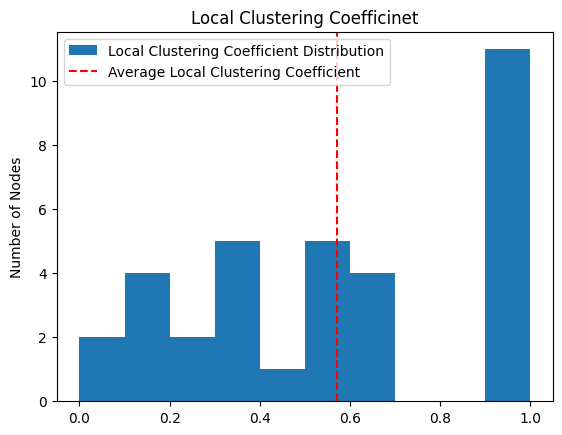

In [ ]:
from matplotlib.lines import lineStyles
# measuing the clustering coeffient

local_clustering_coefficient = nx.algorithms.cluster.clustering(zkc_graph)
avg_local_clustering_coefficient = sum(local_clustering_coefficient.values())/len(local_clustering_coefficient)  # finding  the average

# Express it graphically
plt.hist(local_clustering_coefficient.values(), label="Local Clustering Coefficient Distribution")
plt.axvline(avg_local_clustering_coefficient, color='red', linestyle= 'dashed', label='Average Local Clustering Coefficient')
plt.legend()
plt.ylabel('Number of Nodes')
plt.title("Local Clustering Coefficinet")
plt.show()

We can see the local clustering coefficient and the average local clustering coeffient. If the clusteing coeffient has a low value, this suggests that there is a structural hole in the network. There is a region in the network where there is a missing linkages that would have been otherwise be unpredicted. A big network can be subdivided into several smaller communities also known as cliques. In the context of the social network, this concept refers to the notion of community identification, that a big network can be subdivided into several smaller communites or cliques. In our example of kerate club, this will determine which member will side with Mr Jerry and which will side with Jhon. The degree to which nodes in a network are connected to nodes of same type is refer to the modularity of the network, because the algorithm that we choose that has already been made in networkx.

In [ ]:
# Identifying community/ modularity

from networkx.algorithms.community.modularity_max import greedy_modularity_communities
community = list(greedy_modularity_communities(zkc_graph))
print(len(community))

3


We can the output is 3. That means there is 3 communities in the network.

In [ ]:
community_0 = sorted(community[0])
community_1 = sorted(community[1])
community_2 = sorted(community[2])

print(community_0)
print(community_1)
print(community_2)

[8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
[1, 2, 3, 7, 9, 12, 13, 17, 21]
[0, 4, 5, 6, 10, 11, 16, 19]


Here, we can see all three communites. The first commuinity has the highes number of connections. then the socond community, the third community has the lowest number of nodes/connections. Now, lets visualize the communities or view the community graphicaly.

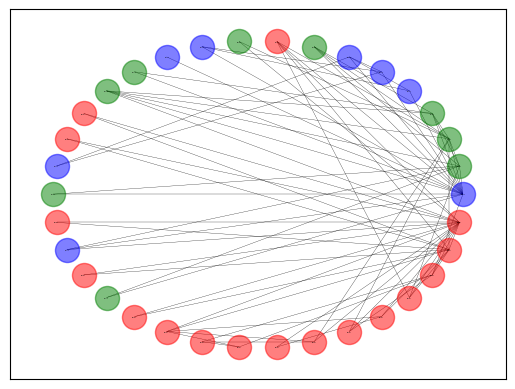

In [ ]:
# visualize community in a graph

nx.draw_networkx_nodes(zkc_graph, circular_position, nodelist=community_0, node_color='r', alpha= 0.5)
nx.draw_networkx_nodes(zkc_graph, circular_position, nodelist=community_1, node_color='g', alpha= 0.5)
nx.draw_networkx_nodes(zkc_graph, circular_position, nodelist=community_2, node_color='b', alpha= 0.5)

nx.draw_networkx_edges(zkc_graph, circular_position, width= 0.2)
nx.draw_networkx_labels(zkc_graph, circular_position, club_labels, font_size=0.9)

plt.show()


Here we can see three distinguish communites in three different colors which are red, green, and blue.